# FlashEats — Class 5 Investigation

## Client escalation

> **“Late deliveries are increasing and customers say our ETA is unreliable. Figure out what is happening before we invest in an AI delay-prediction system.”**

Today is not a syntax lesson. Your job is to use SQL, CSV, JSON and APIs like an FDE:

**define the question → retrieve evidence → validate completeness → reconcile sources → state what you know and what you still cannot know**

### Rules
- Do not train an ML model.
- State your definition of **late** before calculating it.
- Preserve raw API responses.
- Do not silently drop failures.
- If another team gets a different answer, investigate the definition and data grain first.

In [1]:
import json, sqlite3, subprocess, sys, time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 100)
print("Environment ready.")

Environment ready.


In [2]:
# notebook is run from exercises/, the pack folder is right next to it
BASE = Path("FlashEats_Classroom_Pack_V2")
db_path = BASE / "database" / "flasheats.db"
assert db_path.exists(), f"{db_path} not found - start Jupyter from the folder that contains the pack"

print("BASE:", BASE)
print("Exists:", BASE.exists(), "| db:", db_path.exists())

BASE: FlashEats_Classroom_Pack_V2
Exists: True | db: True


## 2. Source map first

Before analysis, predict where you would look for:

| Information | Likely source | Why? |
|---|---|---|
| Promised delivery time | `orders.promised_eta` (SQLite); dispatch API has `current_delivery_eta` | orders stores the ETA for the order, dispatch keeps an updated one |
| Actual delivery time | `orders.actual_delivery_at`, driver_events `delivered` as a check | platform records completion |
| Driver assignment | Dispatch API | dispatch owns assignment and reassignment |
| Customer complaint | `support_tickets.csv` | the customer's own words |
| Restaurant status | `restaurant_status.csv` | restaurant side, partly manual |
| Driver movement/events | `driver_events.json` | driver app events + GPS |

**Discuss:** Which source is authoritative for each fact, and which is only contextual?

Authoritative: `orders` for status and times, dispatch for the current driver, tickets for complaints. Contextual: restaurant status, GPS pings, traffic/weather labels. (Later I found most tickets come before `promised_eta`, so I'm less sure about that field.)

In [3]:
con = sqlite3.connect(db_path)

tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table' ORDER BY name;", con)
display(tables)
display(pd.read_sql("SELECT * FROM orders LIMIT 5;", con))

tickets = pd.read_csv(BASE / "data" / "support_tickets.csv")
restaurant_status = pd.read_csv(BASE / "data" / "restaurant_status.csv")
display(tickets.head())
display(restaurant_status.head())

with open(BASE / "data" / "driver_events.json", "r") as f:
    driver_events = json.load(f)
print("Driver objects:", len(driver_events))
print("First driver:", driver_events[0]["driver_id"], "| events:", len(driver_events[0]["events"]))
display(driver_events[0]["events"][:3])

,name
0,customers
1,drivers
2,orders
3,restaurants


,order_id,customer_id,restaurant_id,driver_id,city,created_at,promised_eta,pickup_at,actual_delivery_at,final_status,distance_km_estimate,traffic_bucket,weather_bucket
0,O00001,C0168,R009,D103,Bengaluru,2026-08-13T12:56:00,2026-08-13T14:11:36,2026-08-13T13:35:49.825561,2026-08-13T14:22:25.035899,delivered,18.00,medium,clear
1,O00002,C0043,R018,D083,Bengaluru,2026-08-01T18:36:00,2026-08-01T19:43:16.627988,2026-08-01T18:58:24.735336,2026-08-01T19:47:14.818533,delivered,9.37,severe,clear
2,O00003,C0855,R010,D039,Bengaluru,2026-08-01T19:35:00,2026-08-01T20:17:52.941967,2026-08-01T19:57:50.820366,2026-08-01T20:13:28.061191,delivered,2.42,medium,clear
3,O00004,C0229,R030,D038,Bengaluru,2026-08-09T18:16:00,2026-08-09T19:30:19.067006,2026-08-09T18:46:48.725485,NaN,cancelled,14.20,high,rain
4,O00005,C0040,R004,D047,Bengaluru,2026-08-06T20:35:00,2026-08-06T21:54:48,2026-08-06T21:18:38.024280,2026-08-06T22:15:49.290713,delivered,18.00,high,clear


,ticket_id,order_id,created_at,category,customer_message
0,T00001,NaN,2026-08-26T23:34:00,late_delivery,My order is already past the promised time.
1,T00002,NaN,2026-08-24T13:49:00,eta_changed,The ETA keeps changing and the food is still n...
2,T00003,NaN,2026-08-25T18:22:00,status_mismatch,The app says picking up but the restaurant say...
3,T00004,O00037,2026-08-09T21:09:00,Late Delivery,The rider has not moved for 15 minutes.
4,T00005,O00040,2026-08-11T20:15:00,late_delivery,My order is already past the promised time.


,order_id,restaurant_id,status,last_updated_at
0,O00676,R040,READY,2026-08-17T13:29:00
1,O01506,R055,Ready,2026-08-27T16:37:00
2,O01484,R032,ready,2026-08-08T19:44:00
3,O00675,R012,handoff,2026-08-22T21:42:00
4,O00078,R027,unknown,2026-08-25T19:35:00


Driver objects: 120
First driver: D001 | events: 135


[{'order_id': 'O00162',
  'type': 'assigned',
  'timestamp': '2026-08-26T17:53:25.977803'},
 {'order_id': 'O00162',
  'type': 'gps_ping',
  'timestamp': '2026-08-26T18:10:59.372420',
  'lat': 12.826339,
  'lon': 77.448282},
 {'order_id': 'O00162',
  'type': 'gps_ping',
  'timestamp': '2026-08-26T18:28:32.767037',
  'lat': 12.876013,
  'lon': 77.477707}]

# Challenge 1 — How large is the late-delivery problem?

Before coding, decide:

- **Late means:** delivered with `actual_delivery_at` after `promised_eta` (delay > 0 min). I also check > 10 min.
- **Denominator:** unique delivered orders (any casing) that have a delivery time.
- **Cancelled orders:** exclude, just report how many.
- **Missing actual delivery timestamp:** exclude from the rate, count them and show how much they could change it.
- **Row grain:** should be one row per order. Checked first.

### Required analysis
1. valid delivered orders,
2. late count and percentage,
3. median lateness among late orders,
4. worst delayed orders,
5. any data-quality issue that changes the metric.

In [4]:
orders_raw = pd.read_sql("SELECT * FROM orders", con)
print("rows:", len(orders_raw), "| unique order_id:", orders_raw["order_id"].nunique())

dup_rows = orders_raw[orders_raw["order_id"].duplicated(keep=False)].sort_values("order_id")
display(dup_rows)
for oid, grp in dup_rows.groupby("order_id"):
    print(oid, "differs in:", [c for c in grp.columns if grp[c].nunique() > 1])

display(orders_raw.groupby("final_status")
        .agg(rows=("order_id", "size"), no_delivery_time=("actual_delivery_at", lambda s: s.isna().sum())))

rows: 1603 | unique order_id: 1600


,order_id,customer_id,restaurant_id,driver_id,city,created_at,promised_eta,pickup_at,actual_delivery_at,final_status,distance_km_estimate,traffic_bucket,weather_bucket
119,O00120,C0501,R040,D045,Bengaluru,2026-08-13T18:15:00,2026-08-13T19:40:24,2026-08-13T18:29:08.055622,2026-08-13T19:34:08.431508,delivered,18.00,severe,clear
1600,O00120,C0501,R040,D045,Bengaluru,2026-08-13T18:15:00,2026-08-13T19:40:24,2026-08-13T18:29:08.055622,2026-08-13T19:34:08.431508,delivered,18.00,medium,clear
722,O00723,C0467,R028,D068,Bengaluru,2026-08-05T21:04:00,2026-08-05T22:19:36,2026-08-05T21:15:24.433874,2026-08-05T22:04:30.928322,delivered,18.00,medium,clear
1601,O00723,C0467,R028,D068,Bengaluru,2026-08-05T21:04:00,2026-08-05T22:19:36,2026-08-05T21:15:24.433874,2026-08-05T22:04:30.928322,delivered,18.00,high,clear
1301,O01302,C0116,R010,D088,Bengaluru,2026-08-26T21:07:00,2026-08-26T22:15:50.273095,2026-08-26T21:35:26.474087,2026-08-26T22:20:27.428561,delivered,14.78,medium,clear
1602,O01302,C0116,R010,D088,Bengaluru,2026-08-26T21:07:00,2026-08-26T22:15:50.273095,2026-08-26T21:35:26.474087,2026-08-26T22:20:27.428561,delivered,14.78,high,clear


O00120 differs in: ['traffic_bucket']
O00723 differs in: ['traffic_bucket']
O01302 differs in: ['traffic_bucket']


,rows,no_delivery_time
final_status,,
Delivered,5,0
cancelled,68,68
delivered,1530,37


In [5]:
df = orders_raw.drop_duplicates("order_id", keep="first").copy()   # 3 duplicate rows, keep first
df["status"] = df["final_status"].str.strip().str.lower()
df["traffic"] = df["traffic_bucket"].str.strip().str.lower()
for col in ["created_at", "promised_eta", "pickup_at", "actual_delivery_at"]:
    df[col] = pd.to_datetime(df[col], format="mixed", errors="coerce")

def minutes(start, end):
    return (df[end] - df[start]).dt.total_seconds() / 60

df["delay_min"] = minutes("promised_eta", "actual_delivery_at")
df["to_pickup_min"] = minutes("created_at", "pickup_at")
df["ride_min"] = minutes("pickup_at", "actual_delivery_at")
df["window_min"] = minutes("created_at", "promised_eta")
df["is_valid"] = df["status"].eq("delivered") & df["actual_delivery_at"].notna()

valid = df[df["is_valid"]].copy()
valid["late"] = valid["delay_min"] > 0
valid["late10"] = valid["delay_min"] > 10

print("unique orders:", len(df), "|", df["status"].value_counts().to_dict())
print("delivered but no delivery time:", int((df["status"].eq("delivered") & df["actual_delivery_at"].isna()).sum()))
print("valid delivered orders:", len(valid))
print(f"late (> 0 min):  {valid['late'].sum()} = {100 * valid['late'].mean():.2f}%")
print(f"late (> 10 min): {valid['late10'].sum()} = {100 * valid['late10'].mean():.2f}%")
late_delays = valid.loc[valid["late"], "delay_min"]
print("lateness of late orders: median", round(late_delays.median(), 2), "| mean", round(late_delays.mean(), 2))
print("median delay over all valid orders:", round(valid["delay_min"].median(), 2))

unique orders: 1600 | {'delivered': 1532, 'cancelled': 68}
delivered but no delivery time: 37
valid delivered orders: 1495
late (> 0 min):  843 = 56.39%
late (> 10 min): 349 = 23.34%
lateness of late orders: median 8.03 | mean 10.52
median delay over all valid orders: 1.41


In [6]:
valid["eta_before_created"] = valid["promised_eta"] < valid["created_at"]
cols = ["order_id", "created_at", "promised_eta", "actual_delivery_at", "delay_min", "traffic", "eta_before_created"]
display(valid.nlargest(10, "delay_min")[cols].round({"delay_min": 1}))

quality = pd.Series({
    "ETA before creation": (df["promised_eta"] < df["created_at"]).sum(),
    "delivered before pickup": (df["actual_delivery_at"] < df["pickup_at"]).sum(),
    "cancelled but has pickup_at": (df["status"].eq("cancelled") & df["pickup_at"].notna()).sum(),
    "no restaurant_id": df["restaurant_id"].isna().sum(),
    "no driver_id": df["driver_id"].isna().sum(),
    "distance exactly 18.0 km": (df["distance_km_estimate"] == 18).sum(),
}, name="orders")
display(quality.to_frame())

,order_id,created_at,promised_eta,actual_delivery_at,delay_min,traffic,eta_before_created
103,O00104,2026-08-09 22:19:00,2026-08-09 22:09:00.000000,2026-08-09 23:36:20.740161,87.3,medium,True
101,O00102,2026-08-11 16:41:00,2026-08-11 16:31:00.000000,2026-08-11 17:57:17.661772,86.3,medium,True
100,O00101,2026-08-24 20:59:00,2026-08-24 20:49:00.000000,2026-08-24 22:14:30.685278,85.5,low,True
102,O00103,2026-08-22 20:11:00,2026-08-22 20:01:00.000000,2026-08-22 21:10:17.342305,69.3,high,True
1080,O01081,2026-08-13 17:14:00,2026-08-13 18:15:46.613098,2026-08-13 19:06:02.677891,50.3,high,False
472,O00473,2026-08-14 18:58:00,2026-08-14 20:17:48.000000,2026-08-14 21:04:00.769224,46.2,high,False
1101,O01102,2026-08-12 18:25:00,2026-08-12 19:31:12.651822,2026-08-12 20:16:09.835907,45.0,medium,False
193,O00194,2026-08-11 17:36:00,2026-08-11 19:01:48.000000,2026-08-11 19:40:08.111510,38.3,high,False
1311,O01312,2026-08-14 19:02:00,2026-08-14 20:17:36.000000,2026-08-14 20:54:36.321890,37.0,medium,False
1402,O01403,2026-08-24 17:26:00,2026-08-24 18:47:36.000000,2026-08-24 19:24:32.047659,36.9,medium,False


,orders
ETA before creation,4
delivered before pickup,5
cancelled but has pickup_at,68
no restaurant_id,3
no driver_id,3
distance exactly 18.0 km,806


In [7]:
delivered_all = df[df["status"].eq("delivered")]
n_missing = delivered_all["actual_delivery_at"].isna().sum()
no_bad_eta = valid[~valid["eta_before_created"]]

# the "historical" style: raw rows, exact 'delivered', no dedup
raw = orders_raw[orders_raw["final_status"].eq("delivered") & orders_raw["actual_delivery_at"].notna()]
raw_delay = (pd.to_datetime(raw["actual_delivery_at"], format="mixed")
             - pd.to_datetime(raw["promised_eta"], format="mixed")).dt.total_seconds()

options = {
    "my definition: > 0 min, valid delivered": (valid["late"].sum(), len(valid)),
    "> 10 min": (valid["late10"].sum(), len(valid)),
    "without the ETA-before-creation orders": (no_bad_eta["late"].sum(), len(no_bad_eta)),
    "missing time counted as late": ((delivered_all["delay_min"] > 0).sum() + n_missing, len(delivered_all)),
    "missing time counted as on time": ((delivered_all["delay_min"] > 0).sum(), len(delivered_all)),
    "all 1600 orders in denominator": ((df["delay_min"] > 0).sum(), len(df)),
    "raw rows, exact 'delivered', no dedup": ((raw_delay > 0).sum(), len(raw)),
}
sens = pd.DataFrame(options, index=["late", "denominator"]).T
sens["late_pct"] = (100 * sens["late"] / sens["denominator"]).round(2)
display(sens)

,late,denominator,late_pct
"my definition: > 0 min, valid delivered",843,1495,56.39
> 10 min,349,1495,23.34
without the ETA-before-creation orders,839,1491,56.27
missing time counted as late,880,1532,57.44
missing time counted as on time,843,1532,55.03
all 1600 orders in denominator,843,1600,52.69
"raw rows, exact 'delivered', no dedup",841,1493,56.33


1. **1495 valid delivered orders.** 1603 rows but 1600 orders; the 3 duplicate ids only differ in `traffic_bucket`, kept the first. 68 cancelled, 37 delivered with no time.
2. **843 late = 56.39%** (> 10 min: 349 = 23.34%).
3. **Median lateness 8.03 min** among late orders.
4. Worst: O00104 (87.3), O00102 (86.3), O00101 (85.5), O00103 (69.3). All have `promised_eta` before `created_at`, so I don't trust them. O01081 (50.3) is the first real-looking one.
5. Issues: threshold (56.39% vs 23.34%), missing times (55.03% to 57.44%), all-orders denominator 52.69%, no dedup with exact 'delivered' 56.33%. Also 806 orders at exactly 18.0 km.

## Checkpoint

Compare your answer with another team.

If your counts differ, investigate:
- duplicate rows,
- cancelled orders,
- missing timestamps,
- late-delivery definition,
- row grain.

Different answers most likely come from the definition: > 10 min gives 23.34%, all 1600 orders gives 52.69%. Cleaning choices (duplicates, "Delivered", missing times) only move it between 55.03% and 57.44%.

# Challenge 2 — Operations says: “Traffic is the problem.”

Test that claim using at least three dimensions.

Possible dimensions:
- traffic,
- weather,
- distance,
- time of day,
- restaurant,
- driver.

### Required output
- 2–3 comparisons,
- one chart or compact table,
- one hypothesis supported by evidence,
- one alternative explanation you cannot rule out.

Separate **association** from **causation**.

In [8]:
def summarise(frame, by):
    return (frame.groupby(by)
            .agg(orders=("order_id", "size"),
                 late_pct=("late", lambda s: round(100 * s.mean(), 1)),
                 avg_delay=("delay_min", lambda s: round(s.mean(), 1)),
                 avg_window=("window_min", lambda s: round(s.mean(), 1)),
                 avg_to_pickup=("to_pickup_min", lambda s: round(s.mean(), 1)),
                 avg_ride=("ride_min", lambda s: round(s.mean(), 1)))
            .sort_values("late_pct", ascending=False))

traffic_tbl = summarise(valid, "traffic")
traffic_tbl["late_pct_clear_only"] = (valid[valid["weather_bucket"] == "clear"]
                                      .groupby("traffic")["late"].mean().mul(100).round(1))
display(traffic_tbl)
display(summarise(valid, "weather_bucket"))

valid["distance_group"] = np.select(
    [valid["distance_km_estimate"] == 18, valid["distance_km_estimate"] < 5,
     valid["distance_km_estimate"] < 10, valid["distance_km_estimate"] < 18],
    ["exactly 18.0", "< 5 km", "5-10 km", "10-18 km"], default="> 18 km")
display(summarise(valid, "distance_group"))

,orders,late_pct,avg_delay,avg_window,avg_to_pickup,avg_ride,late_pct_clear_only
traffic,,,,,,,
high,424,66.5,5.3,72.9,28.7,49.5,64.2
severe,123,65.9,6.3,79.9,27.8,58.4,60.0
medium,588,51.4,2.1,68.6,27.1,43.6,47.9
low,360,49.4,1.2,66.2,27.4,40.0,47.5


,orders,late_pct,avg_delay,avg_window,avg_to_pickup,avg_ride
weather_bucket,,,,,,
heavy_rain,72,73.6,7.7,76.7,26.7,57.7
rain,231,67.1,6.5,72.9,28.7,50.7
clear,1192,53.3,2.2,69.2,27.5,43.9


,orders,late_pct,avg_delay,avg_window,avg_to_pickup,avg_ride
distance_group,,,,,,
> 18 km,3,100.0,25.1,80.2,48.5,56.8
exactly 18.0,749,56.7,3.3,77.4,27.8,53.0
10-18 km,452,56.2,3.2,68.8,27.8,44.1
5-10 km,222,55.9,2.6,56.0,27.1,31.4
< 5 km,69,53.6,1.4,45.9,26.5,20.9


,orders,late_pct,avg_delay
pickup_wait,,,
< 20 min,345,2.3,-8.7
20-30 min,632,51.6,0.6
30-40 min,330,98.2,9.8
40+ min,188,98.4,21.6


correlation with delay_min:
to_pickup_min           0.832
ride_min                0.215
window_min             -0.023
distance_km_estimate    0.066


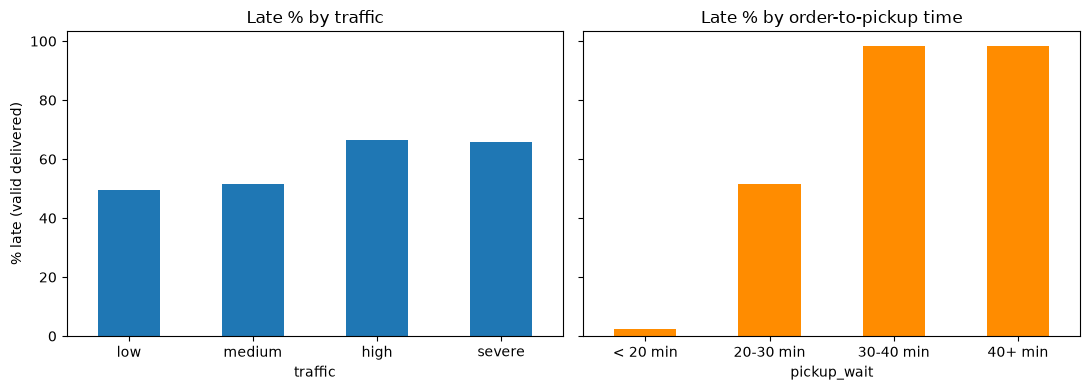

In [9]:
valid["pickup_wait"] = pd.cut(valid["to_pickup_min"], [-np.inf, 20, 30, 40, np.inf], right=False,
                              labels=["< 20 min", "20-30 min", "30-40 min", "40+ min"])
wait_tbl = valid.groupby("pickup_wait", observed=True).agg(
    orders=("order_id", "size"), late_pct=("late", lambda s: round(100 * s.mean(), 1)),
    avg_delay=("delay_min", lambda s: round(s.mean(), 1)))
display(wait_tbl)

corr = valid[["to_pickup_min", "ride_min", "window_min", "distance_km_estimate"]].corrwith(valid["delay_min"])
print("correlation with delay_min:")
print(corr.round(3).to_string())

fig, ax = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
traffic_tbl.loc[["low", "medium", "high", "severe"], "late_pct"].plot.bar(ax=ax[0], rot=0, title="Late % by traffic")
wait_tbl["late_pct"].plot.bar(ax=ax[1], rot=0, color="darkorange", title="Late % by order-to-pickup time")
ax[0].set_ylabel("% late (valid delivered)")
plt.tight_layout()
plt.show()

- Traffic: high 66.5%, severe 65.9%, low 49.4% late. Clear weather only: 64.2% vs 47.5%.
- Weather: heavy_rain 73.6%, clear 53.3%.
- Distance: flat, 53.6% to 56.7%.
- Order-to-pickup: < 20 min 2.3% late, 20-30 min 51.6%, 30-40 min 98.2%. Correlation with delay 0.832 (ride: 0.215).

Pickup wait is similar across traffic buckets (27.1 to 28.7 min), traffic mostly adds ride time (40.0 vs 58.4 min).

Supported hypothesis: delay mostly builds up before pickup. Alternative I can't rule out: slow kitchens vs drivers arriving late, there's no event to split them. Association only, so I wouldn't say traffic causes it.

# Challenge 3 — Customer Support disagrees

Use `support_tickets.csv`.

### Questions
1. What are customers actually complaining about?
2. Which complaint types are most common?
3. Are ticket IDs unique?
4. Does the customer story match the operational story?
5. What can tickets tell you that timestamps cannot?

### Required output
A short **system view vs customer view** comparison.

In [10]:
tix = pd.read_csv(BASE / "data" / "support_tickets.csv")
display(tix.head())
print("rows:", len(tix), "| unique ticket ids:", tix["ticket_id"].nunique(),
      "| repeated ids:", tix["ticket_id"].duplicated().sum(), "| identical rows:", tix.duplicated().sum(),
      "| no order_id:", tix["order_id"].isna().sum())
display(tix[tix["ticket_id"].duplicated(keep=False)])
display(tix["category"].map(repr).value_counts().rename("rows"))   # repr shows the trailing space

,ticket_id,order_id,created_at,category,customer_message
0,T00001,NaN,2026-08-26T23:34:00,late_delivery,My order is already past the promised time.
1,T00002,NaN,2026-08-24T13:49:00,eta_changed,The ETA keeps changing and the food is still n...
2,T00003,NaN,2026-08-25T18:22:00,status_mismatch,The app says picking up but the restaurant say...
3,T00004,O00037,2026-08-09T21:09:00,Late Delivery,The rider has not moved for 15 minutes.
4,T00005,O00040,2026-08-11T20:15:00,late_delivery,My order is already past the promised time.


rows: 202 | unique ticket ids: 201 | repeated ids: 1 | identical rows: 1 | no order_id: 3


,ticket_id,order_id,created_at,category,customer_message
12,T00013,O00090,2026-08-20T18:14:00,late_delivery,My order is already past the promised time.
201,T00013,O00090,2026-08-20T18:14:00,late_delivery,My order is already past the promised time.


category
'late_delivery'        38
'eta_changed'          37
'restaurant_delay'     37
'ready_but_waiting'    33
'status_mismatch'      29
'driver_not_moving'    25
'Late Delivery'         1
'late_delivery '        1
'ETA issue'             1
Name: rows, dtype: int64

In [11]:
tix = tix.drop_duplicates().copy()
# case/space fix only, 'ETA issue' is kept as its own value
tix["cat"] = tix["category"].str.strip().str.lower().str.replace(" ", "_")

tix = tix.join(df.set_index("order_id")[["promised_eta", "delay_min", "is_valid"]], on="order_id")
tix["on_valid_order"] = tix["is_valid"].fillna(False).astype(bool)
tix["late"] = (tix["delay_min"] > 0).astype(float).where(tix["on_valid_order"])
tix["before_eta"] = pd.to_datetime(tix["created_at"], format="mixed") < tix["promised_eta"]

display(tix.groupby("cat").agg(tickets=("ticket_id", "count"),
                               pct_late=("late", lambda s: round(100 * s.mean(), 1)),
                               median_delay=("delay_min", lambda s: round(s.median(), 1)),
                               pct_before_eta=("before_eta", lambda s: round(100 * s.mean(), 1)))
        .sort_values("tickets", ascending=False))

on_valid = tix[tix["on_valid_order"]]
print("tickets on valid delivered orders:", len(on_valid), "| on orders that were on time:", int((on_valid["late"] == 0).sum()))
print("restaurant/handoff tickets:",
      int(tix["cat"].isin(["restaurant_delay", "ready_but_waiting", "status_mismatch"]).sum()), "of", len(tix))
print("opened before the stored promised_eta:", int(tix["before_eta"].sum()), "of", int(tix["order_id"].notna().sum()))

,tickets,pct_late,median_delay,pct_before_eta
cat,,,,
late_delivery,39,86.8,14.8,97.4
eta_changed,37,80.0,7.7,94.6
restaurant_delay,37,75.7,10.5,94.6
ready_but_waiting,33,90.9,12.2,97.0
status_mismatch,29,92.9,12.7,93.1
driver_not_moving,25,68.0,10.4,96.0
eta_issue,1,100.0,5.4,100.0


tickets on valid delivered orders: 197 | on orders that were on time: 34
restaurant/handoff tickets: 99 of 201
opened before the stored promised_eta: 192 of 198


1. Mostly waiting: food not ready, food ready but no rider, app status wrong, ETA changing.
2. late_delivery 39, eta_changed 37, restaurant_delay 37, ready_but_waiting 33, status_mismatch 29, driver_not_moving 25, "ETA issue" 1 (not merged).
3. No, T00013 appears twice. 3 tickets also lack an order_id.
4. Partly. 99 of 201 tickets point at the restaurant/handoff, which fits the pickup-wait finding more than traffic. 34 of 197 are on "on time" orders.
5. What the customer saw: 192 of 198 linked tickets were opened before the stored `promised_eta`.

| | System view | Customer view |
|---|---|---|
| Size | 56.39% late | complaints even on on-time orders |
| Cause | traffic (Ops), pickup wait (data) | restaurant, no rider, ETA changes |

# Challenge 4 — Dispatch API: prove you retrieved everything

Your task:
1. start the API,
2. inspect one response,
3. retrieve **all** records,
4. handle pagination,
5. handle retryable failures,
6. save every successful raw page,
7. prove ingestion completeness.

A successful HTTP `200` on one page does **not** prove the job succeeded.

In [12]:
api_script = BASE / "api" / "mock_dispatch_api.py"
api_proc = subprocess.Popen([sys.executable, str(api_script)],
                            stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
time.sleep(2)
health = requests.get("http://127.0.0.1:8000/health", timeout=10)
print(health.status_code, health.json())

200 {'service': 'flasheats-dispatch-api', 'status': 'ok'}


In [13]:
# Basic API syntax
API_URL = "http://127.0.0.1:8000/dispatch/orders"

response = requests.get(
    API_URL,
    params={"page": 1, "page_size": 50},
    timeout=10
)

print("HTTP:", response.status_code)

if response.ok:
    payload = response.json()
    print("Keys:", payload.keys())
    print("Records on page:", len(payload["data"]))
    print("Has more:", payload["has_more"])
    print("Reported total:", payload["total_records"])

HTTP: 200
Keys: dict_keys(['data', 'has_more', 'page', 'page_size', 'total_records'])
Records on page: 50
Has more: True
Reported total: 1600


In [14]:
RAW_DIR = BASE / "student_output" / "raw_dispatch" / "class5_student"
RAW_DIR.mkdir(parents=True, exist_ok=True)
for f in RAW_DIR.glob("*.json"):   # clear this notebook's own old pages
    f.unlink()

PAGE_SIZE = 50
RETRY_LIMIT = 5


def request_with_retries(page, log):
    """Returns a 200 response for one page, or raises. Retries 429 and 5xx with backoff."""
    delay = 0.5
    for attempt in range(1, RETRY_LIMIT + 1):
        try:
            resp = requests.get(API_URL, params={"page": page, "page_size": PAGE_SIZE}, timeout=10)
            code = resp.status_code
        except requests.RequestException as err:
            resp, code = None, type(err).__name__
        if code == 200:
            return resp
        if isinstance(code, int) and code != 429 and code < 500:
            raise RuntimeError(f"page {page}: HTTP {code}, not retryable: {resp.text[:200]}")
        # 429 tells us how long to wait, otherwise double the wait each time
        body = resp.json() if resp is not None and resp.headers.get("Content-Type", "").startswith("application/json") else {}
        wait = float(body.get("retry_after_seconds", delay))
        log.append({"page": page, "attempt": attempt, "status": code, "body": body, "slept_s": wait})
        print(f"  page {page} attempt {attempt}: {code} -> sleeping {wait}s")
        time.sleep(wait)
        delay *= 2
    raise RuntimeError(f"page {page} failed {RETRY_LIMIT} times in a row, stopping. Dispatch data is incomplete.")


def fetch_all_dispatch_orders():
    """Walks every page, saves each raw 200 body, returns (records, pages_info, retry_log)."""
    records, pages_info, retry_log = [], [], []
    page, has_more = 1, True
    while has_more:
        resp = request_with_retries(page, retry_log)
        out_file = RAW_DIR / f"page_{page:02d}_size{PAGE_SIZE}.json"
        out_file.write_text(resp.text)   # raw body, untouched
        body = resp.json()
        records += body["data"]
        pages_info.append({"page": page, "file": out_file.name, "rows": len(body["data"]),
                           "total_records": body["total_records"], "has_more": body["has_more"]})
        has_more = body["has_more"]
        page += 1
    return records, pd.DataFrame(pages_info), retry_log

In [15]:
dispatch_records, pages_info, retry_log = fetch_all_dispatch_orders()
print("pages:", len(pages_info), "| records:", len(dispatch_records))
print("retries that happened:")
display(pd.DataFrame(retry_log))
display(pages_info.head(6))

  page 3 attempt 1: 500 -> sleeping 0.5s


  page 5 attempt 1: 429 -> sleeping 1.0s


pages: 32 | records: 1600
retries that happened:


,page,attempt,status,body,slept_s
0,3,1,500,"{'error': 'temporary upstream failure', 'retry...",0.5
1,5,1,429,"{'error': 'rate limit exceeded', 'retry_after_...",1.0


,page,file,rows,total_records,has_more
0,1,page_01_size50.json,50,1600,True
1,2,page_02_size50.json,50,1600,True
2,3,page_03_size50.json,50,1600,True
3,4,page_04_size50.json,50,1600,True
4,5,page_05_size50.json,50,1600,True
5,6,page_06_size50.json,50,1600,True


In [16]:
reported = pages_info["total_records"].unique()
dispatch = pd.DataFrame(dispatch_records)
files_on_disk = [RAW_DIR / f for f in pages_info["file"]]
rows_in_files = sum(len(json.loads(p.read_text())["data"]) for p in files_on_disk if p.exists())

proof = pd.DataFrame({
    "expected": [reported[0], reported[0], -(-reported[0] // PAGE_SIZE), len(pages_info), len(pages_info), len(dispatch)],
    "actual": [len(dispatch), dispatch["order_id"].nunique(), len(pages_info),
               sum(p.exists() for p in files_on_disk), len(list(RAW_DIR.glob("*.json"))), rows_in_files],
}, index=["records retrieved", "unique order_ids", "pages fetched", "our raw files exist",
          "json files in the folder", "rows inside raw files"])
proof["ok"] = proof["expected"] == proof["actual"]
display(proof)
print("same total_records on every page:", len(reported) == 1, reported,
      "| last page has_more:", pages_info["has_more"].iloc[-1])

if not (proof["ok"].all() and len(reported) == 1):
    raise RuntimeError("Dispatch ingestion is not complete - not using it.")
print("OK: dispatch ingestion is complete.")

,expected,actual,ok
records retrieved,1600,1600,True
unique order_ids,1600,1600,True
pages fetched,32,32,True
our raw files exist,32,32,True
json files in the folder,32,32,True
rows inside raw files,1600,1600,True


same total_records on every page: True [1600] | last page has_more: False
OK: dispatch ingestion is complete.


In [17]:
both = df[["order_id", "status", "driver_id"]].merge(
    dispatch, on="order_id", how="outer", suffixes=("_orders", "_dispatch"), indicator=True)
print(both["_merge"].value_counts().to_dict())
display(pd.crosstab(both["status"], both["dispatch_status"]))

driver_diff = both[both["driver_id_orders"] != both["driver_id_dispatch"]]
print("driver differs:", len(driver_diff),
      "| reassigned in dispatch:", driver_diff["reassigned_at"].notna().sum(),
      "| driver null in orders:", driver_diff["driver_id_orders"].isna().sum())
has_driver = both["driver_id_orders"].notna()
print("orders.driver_id always equals dispatch original_driver_id:",
      (both.loc[has_driver, "driver_id_orders"] == both.loc[has_driver, "original_driver_id"]).all())

{'both': 1600, 'left_only': 0, 'right_only': 0}


dispatch_status,cancelled,completed
status,,
cancelled,68,0
delivered,0,1532


driver differs: 98 | reassigned in dispatch: 95 | driver null in orders: 3
orders.driver_id always equals dispatch original_driver_id: True


- 32 pages of 50. Page 3 returned 500 and page 5 returned 429 on the first attempt; the retries worked (0.5 s backoff for the 500, 1.0 s from `retry_after_seconds` for the 429).
- The proof table is all True: 1600 records = total_records, 1600 unique ids, 32 pages, 32 raw files in `student_output/raw_dispatch/class5_student/` (nothing else in there), 1600 rows inside them.
- Every order matches `orders` both ways; 98 driver differences = 95 reassigned + 3 null.

# Challenge 5 — Can we attribute the delay?

Inspect `driver_events.json`.

Look for:
- assignment,
- GPS pings,
- pickup,
- delivery.

Then answer:

> **Can we reliably tell when the driver arrived at the restaurant?**

Be precise about:
- **Observed** = directly stored.
- **Inferred** = estimated from another signal, such as GPS.

### Required output

| Event / fact | Observed? | Source | Reliability concern |
|---|---|---|---|
| Driver assigned |  |  |  |
| Driver at restaurant |  |  |  |
| Picked up |  |  |  |
| Delivered |  |  |  |

In [18]:
first_driver = driver_events[0]
print("Driver:", first_driver["driver_id"])
display(pd.DataFrame(first_driver["events"]).head(15))

Driver: D001


,order_id,type,timestamp,lat,lon
0,O00162,assigned,2026-08-26T17:53:25.977803,NaN,NaN
1,O00162,gps_ping,2026-08-26T18:10:59.372420,12.826339,77.448282
2,O00162,gps_ping,2026-08-26T18:28:32.767037,12.876013,77.477707
3,O00162,gps_ping,2026-08-26T18:46:06.161653,12.925686,77.507133
4,O00162,gps_ping,2026-08-26T19:03:39.556270,12.975360,77.536558
5,O00162,picked_up,2026-08-26T18:27:32.131791,NaN,NaN
6,O00162,delivered,2026-08-26T19:21:12.950887,NaN,NaN
7,O00180,assigned,2026-08-08T18:05:08.439625,NaN,NaN
8,O00180,gps_ping,2026-08-08T18:28:19.378257,13.073469,77.716653
9,O00180,gps_ping,2026-08-08T18:51:30.316889,13.071031,77.659475


In [19]:
flat_events = []
for driver in driver_events:
    for pos, event in enumerate(driver["events"]):
        flat_events.append({"driver_id": driver["driver_id"], "pos": pos, **event})
driver_events_df = pd.DataFrame(flat_events)
driver_events_df["ts"] = pd.to_datetime(driver_events_df["timestamp"], format="mixed")

print("Event types:")
display(driver_events_df["type"].value_counts())
print("explicit arrival event present:", driver_events_df["type"].str.contains("arriv").any())

# list order vs time order inside each driver's list
went_back = driver_events_df.sort_values(["driver_id", "pos"]).groupby("driver_id")["ts"].diff() < pd.Timedelta(0)
print("events that are earlier than the event listed before them:", int(went_back.sum()))

key_times = (driver_events_df[driver_events_df["type"] != "gps_ping"]
             .pivot_table(index="order_id", columns="type", values="ts", aggfunc="first"))
print("picked_up earlier than assigned:", int((key_times["picked_up"] < key_times["assigned"]).sum()))

assigned_by = driver_events_df[driver_events_df["type"] == "assigned"].set_index("order_id")["driver_id"]
d = dispatch.set_index("order_id").reindex(assigned_by.index)
print("driver in events = dispatch current driver:", f"{100 * (assigned_by == d['driver_id']).mean():.1f}%",
      "| = original driver:", f"{100 * (assigned_by == d['original_driver_id']).mean():.1f}%")

Event types:


type
gps_ping     5371
assigned     1600
picked_up    1532
delivered    1532
Name: count, dtype: int64

explicit arrival event present: False
events that are earlier than the event listed before them: 2314
picked_up earlier than assigned: 14
driver in events = dispatch current driver: 100.0% | = original driver: 94.1%


In [20]:
pings = driver_events_df[driver_events_df["type"] == "gps_ping"].copy()
rest = pd.read_sql("SELECT restaurant_id, lat AS rest_lat, lon AS rest_lon FROM restaurants", con)
pings = pings.merge(df[["order_id", "restaurant_id"]], on="order_id", how="left").merge(rest, on="restaurant_id", how="left")

def dist_km(lat_a, lon_a, lat_b, lon_b):
    # haversine
    p1, p2 = np.radians(lat_a), np.radians(lat_b)
    dp, dl = p2 - p1, np.radians(lon_b - lon_a)
    return 2 * 6371 * np.arcsin(np.sqrt(np.sin(dp / 2) ** 2 + np.cos(p1) * np.cos(p2) * np.sin(dl / 2) ** 2))

pings["to_rest_km"] = dist_km(pings["lat"], pings["lon"], pings["rest_lat"], pings["rest_lon"])
outside = ~(pings["lat"].between(12.5, 13.5) & pings["lon"].between(77.2, 78.0))
nearest = pings.groupby("order_id")["to_rest_km"].min()
ping_gap = pings.sort_values("ts").groupby("order_id")["ts"].diff().dt.total_seconds() / 60

print("pings:", len(pings), "| outside Bengaluru box:", int(outside.sum()))
print("pings per order (median):", pings.groupby("order_id").size().median(),
      "| median gap between pings (min):", round(ping_gap.median(), 1))
print("nearest ping to restaurant, median km:", round(nearest.median(), 2))
print("orders with a ping within 0.5 km of the restaurant:", int((nearest <= 0.5).sum()), "of", len(nearest))

pings: 5371 | outside Bengaluru box: 189
pings per order (median): 3.0 | median gap between pings (min): 13.4
nearest ping to restaurant, median km: 4.16
orders with a ping within 0.5 km of the restaurant: 17 of 1532


In [21]:
side = key_times.join(df.set_index("order_id")[["promised_eta", "pickup_at", "actual_delivery_at"]])
got_pickup = side.dropna(subset=["picked_up"])
print("driver picked_up same as orders.pickup_at:", int((got_pickup["picked_up"] == got_pickup["pickup_at"]).sum()),
      "of", len(got_pickup), "| no driver pickup at all:", int(side["picked_up"].isna().sum()))

got_deliv = side.dropna(subset=["delivered"])
print("driver delivered same as orders.actual_delivery_at:",
      int((got_deliv["delivered"] == got_deliv["actual_delivery_at"]).sum()),
      "| orders value missing:", int(got_deliv["actual_delivery_at"].isna().sum()))

odd = side[side["actual_delivery_at"] < side["pickup_at"]]
display(odd[["assigned", "picked_up", "pickup_at", "delivered", "actual_delivery_at"]])
print("orders.pickup_at minus driver pickup (min):",
      ((odd["pickup_at"] - odd["picked_up"]).dt.total_seconds() / 60).round(1).tolist())

# sensitivity only: use the driver delivered time where orders has none
gap_rows = got_deliv[got_deliv["actual_delivery_at"].isna()]
extra_late = int((gap_rows["delivered"] > gap_rows["promised_eta"]).sum())
new_late, new_n = int(valid["late"].sum()) + extra_late, len(valid) + len(gap_rows)
print(f"filled {len(gap_rows)} missing times, {extra_late} of them late -> {100 * new_late / new_n:.2f}% ({new_late}/{new_n})")

driver picked_up same as orders.pickup_at: 1527 of 1532 | no driver pickup at all: 68
driver delivered same as orders.actual_delivery_at: 1495 | orders value missing: 37


,assigned,picked_up,pickup_at,delivered,actual_delivery_at
order_id,,,,,
O00051,2026-08-01 15:15:10.334213,2026-08-01 15:25:54.609569,2026-08-01 16:24:51.495665,2026-08-01 16:19:51.495665,2026-08-01 16:19:51.495665
O00052,2026-08-24 17:09:27.940686,2026-08-24 17:19:34.353083,2026-08-24 18:16:16.946011,2026-08-24 18:11:16.946011,2026-08-24 18:11:16.946011
O00053,2026-08-13 17:06:45.255349,2026-08-13 17:42:23.641275,2026-08-13 18:25:53.797613,2026-08-13 18:20:53.797613,2026-08-13 18:20:53.797613
O00054,2026-08-28 20:00:49.745255,2026-08-28 20:23:52.944934,2026-08-28 21:25:10.582862,2026-08-28 21:20:10.582862,2026-08-28 21:20:10.582862
O00055,2026-08-16 12:53:41.483545,2026-08-16 13:20:04.394373,2026-08-16 14:08:05.645770,2026-08-16 14:03:05.645770,2026-08-16 14:03:05.645770


orders.pickup_at minus driver pickup (min): [58.9, 56.7, 43.5, 61.3, 48.0]
filled 37 missing times, 24 of them late -> 56.59% (867/1532)


**Can we reliably tell when the driver arrived at the restaurant?** No, there's no such event and GPS is too sparse to infer it (13.4 min between pings, nearest ping 4.16 km away at the median, only 17 of 1532 orders within 0.5 km).

| Event / fact | Observed? | Source | Reliability concern |
|---|---|---|---|
| Driver assigned | Observed | driver_events `assigned`, dispatch `assigned_at` | 14 orders picked up before assigned |
| Driver at restaurant | Not observed, only inferable | driver_events `gps_ping` | sparse pings, 189 outside Bengaluru |
| Picked up | Observed | driver_events, `orders.pickup_at` | 5 orders differ by 43.5 to 61.3 min |
| Delivered | Observed | driver_events, `orders.actual_delivery_at` | 37 missing in orders (filling them gives 56.59%) |

# Final FDE synthesis — one slide only

Your final slide must answer:

1. **Problem size** — how large is the late-delivery problem?
2. **Evidence** — what appears related to delay?
3. **Trusted sources** — which sources do you trust for which facts?
4. **Uncertainty** — what can you not determine confidently?
5. **Instrumentation recommendation** — what should FlashEats capture/fix next?
6. **Decision** — would you build the AI delay predictor now? Why or why not?

Use language such as:
- “The data shows…”
- “This is associated with…”
- “We cannot determine…”
- “We would need X before concluding Y…”

1. **Problem size:** 56.39% late (843/1495), median 8.03 min. 23.34% more than 10 min late.
2. **Evidence:** long order-to-pickup wait is associated with lateness (98.2% late at 30-40 min). Traffic and rain are associated too.
3. **Trusted sources:** orders (after dedup) for times, dispatch for drivers (1600/1600 retrieved), tickets for customer experience.
4. **Uncertainty:** we cannot determine if the wait is kitchen or driver, or which ETA the customer saw.
5. **Instrumentation:** arrived-at-restaurant and food-ready events, ETA history, fix duplicate rows, one owner for "late".
6. **Decision:** not yet. We would need an agreed label and the pickup-side events first.

In [22]:
con.close()
api_proc.terminate()
api_proc.wait(timeout=10)
print("Session cleanup complete.")

Session cleanup complete.
